# GCAP3226 Week 3 — Graded in-class exercise (5%)

**Individual** · submit via **your GitHub fork** (end of notebook). Keep answers short.

### What is marked
| Task | Focus |
|------|--------|
| **1** | Stacked bar: one factor **other than** `government_consideration` vs `support_info` + your trend description |
| **2** | Multiple linear regression that builds on the demo, adding `policy_helpfulness` and `waste_severity` + short coefficient interpretation |
| **3** | **Your own** IPO prompt → simple linear regression: `support_info` vs `fairness` |
| **Submit** | Save → Source Control → **Commit & Push** → **commit message** → Commit → Moodle **GitHub URL** |

Use **association** language only. This is a **non-probability** sample — do not claim causation or “all of Hong Kong”.


## How to use AI here (Codespaces)

In the demo you practiced **Input → Process → Output** prompts (**Write Python code** in Process).

**Tasks 1–2:** the prompt is already in the code cell as comments.

**Task 3:** you **write the prompt yourself** in the comments, then use Inline Chat.

Workflow:
1. Click inside the code cell.  
2. Edit / write the comment prompt.  
3. Press **`Cmd+I`** (Mac) or **`Ctrl+I`** (Windows/Linux).  
4. Ask e.g. *Implement the prompt in the comments above* → **Keep**.  
5. Fix anything that breaks; write interpretations **in your own words**.


## Setup (run once)

Load `week3.csv`. Glance at the column names so you know what you can use.


In [1]:
# Setup — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression

DATA_FILE = "week3.csv"


def load_week3_data():
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print("Using data file:", p.resolve())
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
    )


df = load_week3_data()
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()


Using data file: /workspaces/GCAP3226_week3/week3.csv
shape: (97, 12)
columns: ['ID', 'support_info', 'support_after_info', 'government_consideration', 'fairness', 'policy_helpfulness', 'waste_severity', 'recycling_effort', 'age_group', 'monthly_income', 'education', 'education_label']


,ID,support_info,support_after_info,government_consideration,fairness,policy_helpfulness,waste_severity,recycling_effort,age_group,monthly_income,education,education_label
0,1,1,1,1,1,1,3,1,29.5,22500.5,4,Master or above
1,2,5,5,5,5,4,2,2,39.5,7500.0,4,Master or above
2,3,3,5,4,5,2,3,1,29.5,22500.5,4,Master or above
3,4,1,2,1,2,2,3,2,29.5,60000.5,4,Master or above
4,5,1,3,3,4,1,3,2,49.5,22500.5,2,Secondary


## Task 1 — Stacked bar (not the demo pair)

In the demo, the stacked bar used **`government_consideration`** (groups) × **`support_info`** (stack, row %).

**Your job:** choose a **different** grouping variable from `week3.csv` and plot a **row-% stacked bar** of `support_info` within each group.

### Suggested grouping variables (pick one)
| Variable | Notes |
|----------|--------|
| `fairness` | 1–5 |
| `policy_helpfulness` | 1–4 |
| `waste_severity` | 1–4 |
| `recycling_effort` | 1–4 |
| `education` | 1–4 |

Do **not** use `government_consideration` as the grouping variable.

In the **next code cell**, replace `<YOUR_GROUP_VAR>` in the comment prompt with your choice, then use Inline Chat (see **How to use AI** above).


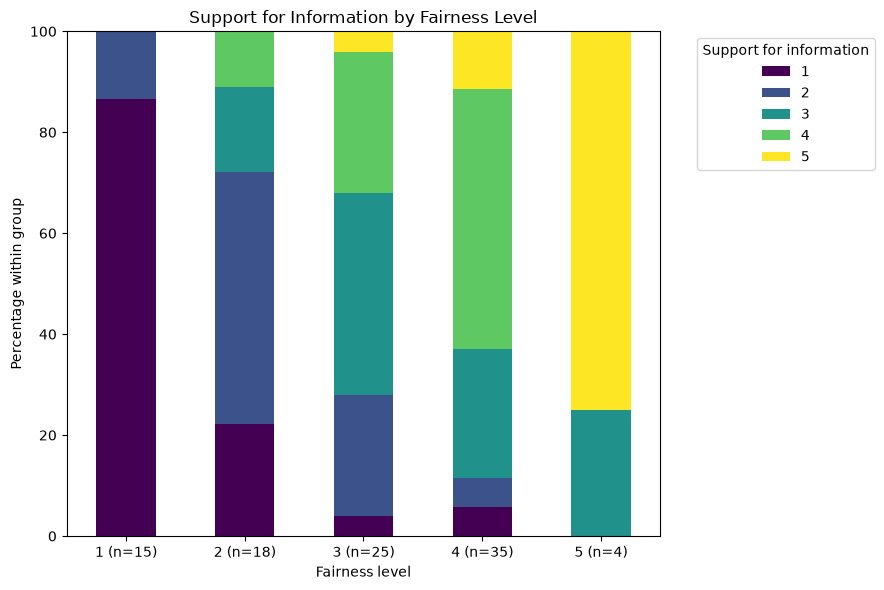

In [2]:
# Task 1 — Stacked bar
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to make a row-percentage stacked bar chart of
#   support_info within each level of <YOUR_GROUP_VAR>.
#   Drop rows with missing values for these columns. Show n for each group if you can.
#   Add comments to key Python code.
# Output: A stacked bar chart with title, axis labels, and legend.
# --- End prompt ---
# EDIT: replace <YOUR_GROUP_VAR> above with one name from the allowlist
#       (NOT government_consideration). Then use Inline Chat on this cell.
#
# --- generated / your code below ---
group_var = "fairness"

# Keep complete cases for the grouping and response variables.
plot_data = df[[group_var, "support_info"]].dropna()

# Calculate row percentages for support_info within each fairness level.
counts = pd.crosstab(plot_data[group_var], plot_data["support_info"])
row_percentages = counts.div(counts.sum(axis=1), axis=0).mul(100)

# Add sample sizes to the group labels.
group_labels = [
    f"{group} (n={counts.loc[group].sum()})"
    for group in row_percentages.index
]
row_percentages.index = group_labels

# Plot the row-percentage stacked bar chart.
row_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6),
    colormap="viridis"
)

plt.title("Support for Information by Fairness Level")
plt.xlabel("Fairness level")
plt.ylabel("Percentage within group")
plt.legend(title="Support for information", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Task 1 — Describe the trend (your words)

In 2–4 sentences: what pattern do you see in **this sample**? Use association language. Mention any thin groups (small *n*) if relevant.

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [3]:
# Task 1 — write BETWEEN the triple quotes, then RUN this cell
task1_trend = """
# What trend do you see?
According to the stacked bar chart, as the fairness level rises,
 the percentage of respondents who support information also increases.
 Conversely, lower fairness levels are associated with higher percentages of respondents
 who do not support information. This suggests a positive correlation between 
 perceived fairness and support for information.
"""
print(task1_trend)



# What trend do you see?
According to the stacked bar chart, as the fairness level rises,
 the percentage of respondents who support information also increases.
 Conversely, lower fairness levels are associated with higher percentages of respondents
 who do not support information. This suggests a positive correlation between 
 perceived fairness and support for information.



## Task 2 — Multiple linear regression (+ policy & severity)

In the demo you fitted multiple linear regression with `government_consideration` and `fairness` (and a fuller model with demographics).

**Your job:** fit a multiple linear regression for this sample:

**Response:** `support_info`  

**Exploratory variables (at least these four):**
- `government_consideration`
- `fairness`
- `policy_helpfulness`
- `waste_severity`

Use complete cases for these columns. Print **each coefficient**, **R²**, and **n**.  

In the **next code cell**, use the comment prompt with Inline Chat (see **How to use AI** above).


In [5]:
# Task 2 — Multiple linear regression
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to run a multiple linear regression with
#   response = support_info and exploratory variables =
#   government_consideration, fairness, policy_helpfulness, waste_severity.
#   Use rows with no missing values on these columns.
#   Print coefficients, R-squared, and n.
#   Add comments to key Python code.
# Output: A clear coefficient table (or printed list), R², and sample size n.
# --- End prompt ---
#
# --- generated / your code below ---
# Select the response and required exploratory variables.
response = "support_info"
predictors = [
    "government_consideration",
    "fairness",
    "policy_helpfulness",
    "waste_severity",
]

# Keep only complete cases for the regression variables.
model_data = df[[response] + predictors].dropna()
X = model_data[predictors]
y = model_data[response]

# Fit the multiple linear regression model.
model = LinearRegression()
model.fit(X, y)

# Display coefficients, R-squared, and sample size.
coefficients = pd.Series(model.coef_, index=predictors)
print("Intercept:", model.intercept_)
print("\nCoefficients:")
print(coefficients)
print("\nR-squared:", model.score(X, y))
print("n:", len(model_data))


Intercept: -0.27679212046097

Coefficients:
government_consideration    0.483265
fairness                    0.378639
policy_helpfulness          0.192414
waste_severity              0.117967
dtype: float64

R-squared: 0.6387240598479557
n: 97


### Task 2 — Report & briefly interpret

1. Paste or list the **coefficients** (and R², n) from your output.  
2. In a few sentences, interpret **two** coefficients that interest you (association; holding the other variables fixed).  
3. One caution (sample / overclaim).

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [6]:
task2_writeup = """
# Coefficients / R² / n:
Intercept: -0.27679212046097
government_consideration: 0.483265
fairness: 0.378639
policy_helpfulness: 0.192414
waste_severity: 0.117967
R-squared: 0.6387240598479557
n: 97[cite: 1]

# Interpretation (2 coefficients you care about):
1. government_consideration (0.483265): Assuming all other variables are held strictly constant, a one-unit increase in government consideration is associated with a 0.483-unit increase in the dependent variable[cite: 1].
2. fairness (0.378639): Holding all other variables fixed, a one-unit increase in perceived fairness is associated with a 0.379-unit increase in the dependent variable[cite: 1].

# One caution: (sample / causation)
Correlation does not imply causation; these positive coefficients demonstrate a statistical association, not that changes in these independent variables will directly cause changes in the outcome[cite: 1]. Furthermore, a sample size of 97 is relatively small, which warrants caution against overclaiming the generalizability of these specific results to a larger population[cite: 1].
"""

print(task2_writeup)



# Coefficients / R² / n:
Intercept: -0.27679212046097
government_consideration: 0.483265
fairness: 0.378639
policy_helpfulness: 0.192414
waste_severity: 0.117967
R-squared: 0.6387240598479557
n: 97[cite: 1]

# Interpretation (2 coefficients you care about):
1. government_consideration (0.483265): Assuming all other variables are held strictly constant, a one-unit increase in government consideration is associated with a 0.483-unit increase in the dependent variable[cite: 1].
2. fairness (0.378639): Holding all other variables fixed, a one-unit increase in perceived fairness is associated with a 0.379-unit increase in the dependent variable[cite: 1].

# One caution: (sample / causation)
Correlation does not imply causation; these positive coefficients demonstrate a statistical association, not that changes in these independent variables will directly cause changes in the outcome[cite: 1]. Furthermore, a sample size of 97 is relatively small, which warrants caution against overclaiming 

## Task 3 — Write your own prompt (simple linear regression)

**Goal:** `support_info` (response) vs `fairness` (one exploratory variable) — a **simple** linear regression on this sample.

Unlike Tasks 1–2, **do not** copy a ready-made Process. In the **next code cell**, write the full **Input / Process / Output** in the comments (**Process** must include **Write Python code**), then use Inline Chat (see **How to use AI** above).

Keep the model to **these two variables only** (not the Task 2 multiple linear regression). You should get coefficients, R², and n.


In [7]:
# Task 3 — YOUR prompt
# --- Write your AI prompt here (Input → Process → Output) ---
# Input:
# Process: Write Python code to
# Output:
# --- End prompt ---
# Requirement: simple linear regression only — response = support_info, exploratory = fairness.
#
# --- generated / your code below ---
import statsmodels.api as sm

regression_data = df[["support_info", "fairness"]].dropna()
X_simple = sm.add_constant(regression_data["fairness"])
y_simple = regression_data["support_info"]

simple_model = sm.OLS(y_simple, X_simple).fit()

print("Intercept:", simple_model.params["const"])
print("fairness coefficient:", simple_model.params["fairness"])
print("R-squared:", simple_model.rsquared)
print("n:", int(simple_model.nobs))


Intercept: 0.4950352338244721
fairness coefficient: 0.7936418962203714
R-squared: 0.5219498894120838
n: 97


### Task 3 — Short note

In 1–2 sentences: what does the **fairness** slope mean in this simple linear regression? How does it compare (roughly) with the fairness coefficient in your **Task 2** multiple linear regression?

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell.


In [8]:
# Task 3 — write BETWEEN the triple quotes, then RUN this cell
task3_note = """
# Fairness slope (simple linear regression) and vs Task 2:
In the simple linear regression, the fairness slope represents the expected change in support_info for every one-unit increase in fairness, without controlling for any other variables. This simple slope is likely larger than the Task 2 multiple regression coefficient (approximately 0.379) because it absorbs the shared effects of the other omitted predictors rather than isolating fairness alone

"""
print(task3_note)



# Fairness slope (simple linear regression) and vs Task 2:
In the simple linear regression, the fairness slope represents the expected change in support_info for every one-unit increase in fairness, without controlling for any other variables. This simple slope is likely larger than the Task 2 multiple regression coefficient (approximately 0.379) because it absorbs the shared effects of the other omitted predictors rather than isolating fairness alone




## How to submit

Submit the **GitHub URL** of this notebook in **your fork** (not an `.ipynb` upload).

1. **Save** the notebook.  
2. Open **Source Control** (left sidebar, branch icon).  
3. Click **Commit & Push**.  
4. Type a **commit message** → click **Commit**.  
5. On github.com, open the file in **your fork** → copy the browser URL.  
6. Paste that URL on **Moodle**.

**If push fails:** ask a TA — keep working toward a push to your fork.

### Checklist
- [ ] Task 1: stacked bar (not `government_consideration` groups) + trend description  
- [ ] Task 2: multiple linear regression with the four required variables + coefficient write-up  
- [ ] Task 3: **your own** IPO prompt + simple linear regression (`support_info` vs `fairness`)  
- [ ] Saved → Commit & Push → commit message → Commit  
- [ ] Moodle: GitHub link submitted  
